# U-Net Reconstruction Baseline

## Introduction


This project investigates the generation of furniture photographs from Canny edge sketches using paired image-to-image learning. The previous notebook produced 14318 usable 256 × 256 sketch-photo pairs while preserving the original training, validation, and test splits.

This notebook implements a reconstruction-only U-Net trained with L1 loss, without a discriminator or adversarial training. It establishes a baseline for how much structural and appearance information can be reconstructed directly from the edge maps. Next Notebook 04 will reuse the same U-Net architecture within Pix2Pix, allowing the effect of adversarial training to be evaluated separately.

The notebook covers the Colab environment and data loading, dataset verification, U-Net implementation, checkpointed pilot and full training, and evaluation of reconstructed validation images.

## Setup and Environment

Google Colab provides the execution environment for model training. The prepared dataset archive is stored in Google Drive and extracted to the Colab local disk for faster image loading. Model checkpoints remain in Google Drive so training can be resumed after a runtime disconnection.

In [3]:
# Imports, Random Seeds, and Runtime Check

from pathlib import Path
import random
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Fixed 256 × 256 inputs allow cuDNN to select faster algorithms.
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not enabled.")

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
Device: cpu
GPU is not enabled.


The prepared dataset archive is stored in Google Drive and extracted to the Colab local disk for faster image loading. Model checkpoints remain in Google Drive so training can be resumed after a runtime disconnection.

To reproduce this setup, the prepared archive must be placed inside the `colab_data` directory. Normally, only `DRIVE_ROOT` needs to be changed.

In [4]:
# Google Drive and Environment-Dependent Paths

from google.colab import drive

drive.mount("/content/drive")

# The only path that should normally needs to change
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Sketch2Furniture"
)

ARCHIVE_PATH = (
    DRIVE_ROOT / "colab_data" / "paired_dataset.tar"
)

CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "unet_baseline"
)

LOCAL_ROOT = Path("/content")

PAIRED_DATA_DIR = (
    LOCAL_ROOT / "data" / "processed" / "paired"
)

PREPARED_METADATA_PATH = (
    PAIRED_DATA_DIR / "prepared_metadata.csv"
)

EXTRACTION_MARKER = (
    PAIRED_DATA_DIR / ".extraction_complete"
)

if not DRIVE_ROOT.is_dir():
    raise FileNotFoundError(
        f"Drive project folder not found: {DRIVE_ROOT}"
    )

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"Prepared dataset archive not found: {ARCHIVE_PATH}"
    )

CKPT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

archive_size_gib = ARCHIVE_PATH.stat().st_size / (1024 ** 3)

print(f"Drive root: {DRIVE_ROOT}")
print(f"Archive path: {ARCHIVE_PATH}")
print(f"Archive size: {archive_size_gib:.2f} GiB")
print(f"Checkpoint directory: {CKPT_DIR}")

Mounted at /content/drive
Drive root: /content/drive/MyDrive/Sketch2Furniture
Archive path: /content/drive/MyDrive/Sketch2Furniture/colab_data/paired_dataset.tar
Archive size: 1.02 GiB
Checkpoint directory: /content/drive/MyDrive/Sketch2Furniture/checkpoints/unet_baseline


In [6]:
# Verify the Uploaded Archive

checksum_result = subprocess.run(
    ["sha256sum", str(ARCHIVE_PATH)],
    capture_output=True,
    text=True,
    check=True,
)

archive_checksum = checksum_result.stdout.split()[0]

print(f"Archive SHA256: {archive_checksum}")

Archive SHA256: 91c2d6fa631af7df728318847d0cd9f0d79b8c5006e8ae5deb65208f34460dd2


The prepared image pairs are stored in Google Drive as a single archive for convenient transfer between Colab sessions. After verifying its checksum, the archive is extracted to Colab's temporary local storage, where loading thousands of individual images is faster than reading them through the mounted Drive.

A marker file is created after successful extraction, allowing the cell to be re-run without repeating the work during the same runtime. Because Colab local storage is temporary, the extraction is performed again when a new runtime starts.

In [5]:
# Extract the Prepared Dataset to Colab Local Storage

extraction_ready = (
    EXTRACTION_MARKER.is_file()
    and PREPARED_METADATA_PATH.is_file()
)

if not extraction_ready:
    print("Extracting the prepared dataset...")

    subprocess.run(
        [
            "tar",
            "-xf",
            str(ARCHIVE_PATH),
            "-C",
            str(LOCAL_ROOT),
        ],
        check=True,
    )

    if not PREPARED_METADATA_PATH.is_file():
        raise FileNotFoundError(
            "Extraction completed, but prepared_metadata.csv "
            "was not found."
        )

    EXTRACTION_MARKER.touch()
    print("Dataset extracted successfully.")
else:
    print("Prepared dataset is already extracted.")

png_count = sum(
    1 for _ in PAIRED_DATA_DIR.rglob("*.png")
)

print(f"PNG files extracted: {png_count}")
print(f"Metadata path: {PREPARED_METADATA_PATH}")

Extracting the prepared dataset...
Dataset extracted successfully.
PNG files extracted: 28668
Metadata path: /content/data/processed/paired/prepared_metadata.csv


### Observation

The extraction restored 28668 PNG files, representing all 14334 generated edge-photo pairs. This total includes the 16 pairs whose edge maps were completely blank. Those pairs were excluded from `prepared_metadata.csv` during data preparation, although their files were retained in the directory structure.

The metadata file therefore defines the 14318 usable pairs for training and evaluation; a directory scan does not.

## Loading the Prepared Metadata

The prepared metadata serves as the authoritative manifest for training and evaluation. It preserves the original dataset splits and excludes the 16 blank image pairs identified during data preparation. Although those files remain in the extracted folders, they are not loaded by the datasets.

In [6]:
# Load the Prepared Metadata

prepared_metadata = pd.read_csv(
    PREPARED_METADATA_PATH
)

print(f"Metadata rows: {len(prepared_metadata)}")
print(f"Metadata columns: {prepared_metadata.shape[1]}")

preview_columns = [
    "pair_id",
    "split",
    "category",
    "style",
    "width",
    "height",
    "generation_success",
]

metadata_preview = (
    prepared_metadata[preview_columns]
    .head()
    .rename(
        columns={
            "width": "source_width",
            "height": "source_height",
        }
    )
)

display(metadata_preview)

Metadata rows: 14318
Metadata columns: 30


,pair_id,split,category,style,source_width,source_height,generation_success
0,pair_00001,train,beds,Asian,350,350,True
1,pair_00002,train,beds,Asian,350,350,True
2,pair_00003,train,beds,Asian,350,350,True
3,pair_00004,train,beds,Asian,350,350,True
4,pair_00005,validation,beds,Asian,350,350,True


### Observation

The prepared metadata contains 14318 usable pairs and preserves their original dataset splits, categories, and styles.

The `source_width` and `source_height` columns shown in the preview describe the original images inspected in Notebook 01. They were renamed in the preview to distinguish them from the prepared edge-photo pairs, which were resized to 256 × 256 during data preparation. The dimensions of the generated files will be verified directly before constructing the datasets.

In [7]:
# Inspect the Dataset Split Counts

split_summary = (
    prepared_metadata["split"]
    .value_counts(sort=False)
    .rename_axis("split")
    .reset_index(name="pair_count")
)

split_summary["percentage"] = (
    split_summary["pair_count"]
    .div(len(prepared_metadata))
    .mul(100)
    .round(2)
)

display(split_summary)

print(f"Total usable pairs: {split_summary['pair_count'].sum()}")

,split,pair_count,percentage
0,train,9718,67.87
1,validation,1708,11.93
2,test,2892,20.20


Total usable pairs: 14318


### Observation

The metadata preserves the original dataset split distribution: 9718 pairs belong to the training set, 1708 to validation, and 2892 to testing. Together, they account for all 14318 usable pairs.

Keeping these predefined splits avoids reshuffling related images across subsets and maintains consistency with the earlier stages of the project.

The stored `input_path` and `target_path` values refer to the local environment used during data preparation. For Colab, only the path prefix is replaced; each file's split, subdirectory, and filename remain unchanged. The original `source_path` is not rebuilt because the source images are not required for training.

In [7]:
# Rebuild the Prepared Image Paths for Colab

def rebuild_colab_path(stored_path):
    stored_path = Path(stored_path)
    path_parts = stored_path.parts

    if "paired" not in path_parts:
        raise ValueError(
            f"'paired' directory not found in path: {stored_path}"
        )

    paired_index = path_parts.index("paired")
    relative_path = Path(
        *path_parts[paired_index + 1:]
    )

    return PAIRED_DATA_DIR / relative_path


for column in ("input_path", "target_path"):
    prepared_metadata[column] = (
        prepared_metadata[column]
        .map(rebuild_colab_path)
    )

    missing_count = (
        prepared_metadata[column]
        .map(lambda path: not path.is_file())
        .sum()
    )

    print(f"Missing {column} files: {missing_count}")
    print(f"Example {column}: {prepared_metadata[column].iloc[0]}")

Missing input_path files: 0
Example input_path: /content/data/processed/paired/train/A/pair_00001.png
Missing target_path files: 0
Example target_path: /content/data/processed/paired/train/B/pair_00001.png


### Observation

The input and target paths were successfully rebuilt for the Colab environment. No referenced files are missing, confirming that all 14318 usable pairs are available after extraction.

Before constructing the PyTorch datasets, the generated files are inspected directly to confirm their actual dimensions and color modes. This verifies the prepared training representation without relying on the original source-image dimensions retained in the metadata.

In [8]:
from collections import Counter

def collect_image_properties(paths):
    sizes = Counter()
    modes = Counter()
    for path in paths:
        with Image.open(path) as image:
            sizes[image.size] += 1
            modes[image.mode] += 1
    return sizes, modes

for column in ("input_path", "target_path"):
    sizes, modes = collect_image_properties(
        prepared_metadata[column]
    )

    print(f"{column} sizes: {sizes.most_common()}")
    print(f"{column} modes: {modes.most_common()}")

input_path sizes: [((256, 256), 14318)]
input_path modes: [('L', 14318)]
target_path sizes: [((256, 256), 14318)]
target_path modes: [('RGB', 14318)]


### Observation

All 14318 usable input images measure 256 × 256 and use mode `L` (single-channel grayscale), while all corresponding targets measure 256 × 256 and use mode `RGB` (three-channel color). No deviations were found.

Together with the matching archive checksum and the absence of missing referenced files, these results confirm that the prepared dataset was transferred and extracted successfully and that its representation matches the specification established in Notebook 02.

## Dataset and Data Loaders

This section constructs the PyTorch input pipeline for the prepared edge-photo pairs. A custom dataset class will load each grayscale edge map with its corresponding RGB target, normalize both images to the range `[-1, 1]`, and preserve the pair identifier for traceability. Separate datasets and data loaders will then be created for the predefined training, validation, and test splits.

Data augmentation is deliberately limited to a random horizontal flip with a probability of 0.5, applied only to training pairs. The input and target are flipped together to preserve their exact spatial correspondence. Horizontal flipping provides a plausible alternative view of furniture without changing its structure, while vertical flips and large rotations would create unrealistic orientations, and random crops could remove important parts of an object. Validation and test pairs remain unchanged to ensure deterministic and comparable evaluation.

In [9]:
# Define the Paired Furniture Dataset

class PairedFurnitureDataset(Dataset):
    def __init__(self, metadata, augment=False):
        self.metadata = (
            metadata
            .reset_index(drop=True)
            .copy()
        )
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        with Image.open(row["input_path"]) as image:
            input_image = image.convert("L")

        with Image.open(row["target_path"]) as image:
            target_image = image.convert("RGB")

        if self.augment and torch.rand(1).item() < 0.5:
            input_image = TF.hflip(input_image)
            target_image = TF.hflip(target_image)

        input_tensor = (
            TF.to_tensor(input_image)
            .mul(2)
            .sub(1)
        )
        target_tensor = (
            TF.to_tensor(target_image)
            .mul(2)
            .sub(1)
        )

        return {
            "input": input_tensor,
            "target": target_tensor,
            "pair_id": row["pair_id"],
        }

In [10]:
# Create the Dataset Instances

train_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "train"
    ],
    augment=True,
)

validation_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "validation"
    ],
)

test_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "test"
    ],
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 9718
Validation samples: 1708
Test samples: 2892


In [11]:
# Inspect One Dataset Sample

sample = validation_dataset[0]

print(f"Sample keys: {list(sample.keys())}")
print(f"Pair ID: {sample['pair_id']}")

for name in ("input", "target"):
    tensor = sample[name]

    print(f"\n{name.capitalize()} shape: {tuple(tensor.shape)}")
    print(f"{name.capitalize()} dtype: {tensor.dtype}")
    print(
        f"{name.capitalize()} range: "
        f"[{tensor.min().item():.3f}, "
        f"{tensor.max().item():.3f}]"
    )

Sample keys: ['input', 'target', 'pair_id']
Pair ID: pair_00005

Input shape: (1, 256, 256)
Input dtype: torch.float32
Input range: [-1.000, 1.000]

Target shape: (3, 256, 256)
Target dtype: torch.float32
Target range: [-1.000, 1.000]


In [13]:
# Reverse the Image Normalization for Visualization

def denormalize(tensor):
    """Map image tensor values from [-1, 1] back to [0, 1]."""
    return tensor.add(1).div(2)

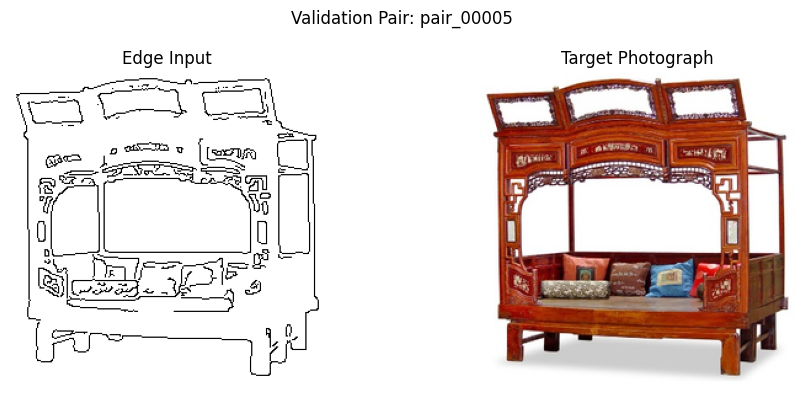

In [14]:
# Visualize One Dataset Sample

input_image = (
    denormalize(sample["input"])
    .squeeze(0)
    .numpy()
)

target_image = (
    denormalize(sample["target"])
    .permute(1, 2, 0)
    .numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(
    input_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Edge Input")

axes[1].imshow(target_image)
axes[1].set_title("Target Photograph")

for axis in axes:
    axis.axis("off")

fig.suptitle(f"Validation Pair: {sample['pair_id']}")
plt.tight_layout()
plt.show()

### Observation

The inspected validation sample has the expected tensor structure: a single-channel edge input and a three-channel RGB target, both represented as `float32` tensors with spatial dimensions of 256 × 256 and values normalized to `[-1, 1]`. The pair identifier is also retained for traceability.

After reversing the normalization for visualization, the input and target remain spatially aligned and clearly represent the same furniture instance. This confirms that the dataset class loads and transforms a prepared pair correctly without disrupting its correspondence.

In [15]:
# Create the Data Loaders

BATCH_SIZE = 8
NUM_WORKERS = 2

loader_settings = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
    "drop_last": False,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_settings,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_settings,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_settings,
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Pinned memory: {loader_settings['pin_memory']}")

Batch size: 8
Training batches: 1215
Validation batches: 214
Test batches: 362
Pinned memory: False


In [16]:
# Inspect One Data Loader Batch

batch = next(iter(validation_loader))

print(f"Batch keys: {list(batch.keys())}")
print(f"Samples in batch: {len(batch['pair_id'])}")
print(f"First pair ID: {batch['pair_id'][0]}")

for name in ("input", "target"):
    tensor = batch[name]

    print(f"\n{name.capitalize()} shape: {tuple(tensor.shape)}")
    print(f"{name.capitalize()} dtype: {tensor.dtype}")
    print(
        f"{name.capitalize()} range: "
        f"[{tensor.min().item():.3f}, "
        f"{tensor.max().item():.3f}]"
    )

Batch keys: ['input', 'target', 'pair_id']
Samples in batch: 8
First pair ID: pair_00005

Input shape: (8, 1, 256, 256)
Input dtype: torch.float32
Input range: [-1.000, 1.000]

Target shape: (8, 3, 256, 256)
Target dtype: torch.float32
Target range: [-1.000, 1.000]


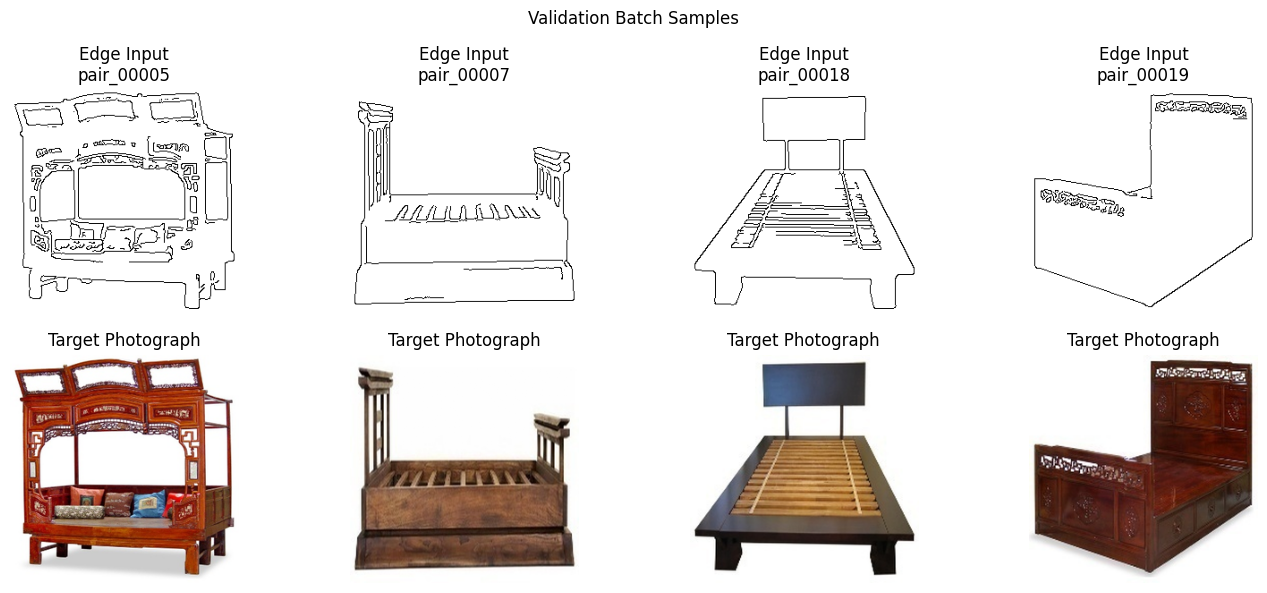

In [17]:
# Visualize Data Loader Batch Samples

num_display_pairs = 4

fig, axes = plt.subplots(2, num_display_pairs, figsize=(14, 6),)

for index in range(num_display_pairs):
    input_image = (
        denormalize(batch["input"][index])
        .squeeze(0)
        .numpy()
    )

    target_image = (
        denormalize(batch["target"][index])
        .permute(1, 2, 0)
        .numpy()
    )

    axes[0, index].imshow(
        input_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[0, index].set_title(
        f"Edge Input\n{batch['pair_id'][index]}"
    )

    axes[1, index].imshow(target_image)
    axes[1, index].set_title("Target Photograph")

for axis in axes.ravel():
    axis.axis("off")

fig.suptitle("Validation Batch Samples")
plt.tight_layout()
plt.show()

### Observation

With a batch size of 8, the training, validation, and test data loaders contain 1215, 214, and 362 batches, respectively. Training samples are shuffled, while validation and test ordering remains fixed. Incomplete final batches are retained so that every available pair is used.

The inspected validation batch has the expected shapes of `(8, 1, 256, 256)` for edge inputs and `(8, 3, 256, 256)` for target photographs. Both tensors use the `float32` data type and remain normalized to `[-1, 1]`.

The four visualized pairs are distinct, and each edge map corresponds spatially to its target photograph. All four examples are beds because the validation loader follows the fixed, category-grouped metadata ordering, placing samples from the same category in its early batches; this does not imply that the dataset contains only beds. The visualization confirms that the data loader preserves the pairing and tensor representation established by the dataset class.

## U-Net Model Architecture

This section defines the U-Net used as the reconstruction-only baseline. The model receives a single-channel edge map and generates a three-channel RGB image. Its encoder progressively extracts higher-level features, while the decoder restores the original spatial resolution. Skip connections transfer spatial details directly between corresponding encoder and decoder levels.

The output layer uses a `tanh` activation so that generated images match the `[-1, 1]` normalization applied to the targets. The same U-Net architecture will later be used as the Pix2Pix generator, allowing the effect of adversarial training to be compared against the L1-only baseline.

In [18]:
# Define the U-Net Building Blocks

class DownBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        normalize=True,
    ):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not normalize,
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=False,
    ):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [20]:
# Define the U-Net Generator

class UNetGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_channels=3,
    ):
        super().__init__()

        # Encoder
        self.down1 = DownBlock(
            input_channels, 64, normalize=False
        )
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)
        self.down5 = DownBlock(512, 512)
        self.down6 = DownBlock(512, 512)
        self.down7 = DownBlock(512, 512)
        self.down8 = DownBlock(
            512, 512, normalize=False
        )

        # Decoder
        self.up1 = UpBlock(512, 512, dropout=True)
        self.up2 = UpBlock(1024, 512, dropout=True)
        self.up3 = UpBlock(1024, 512, dropout=True)
        self.up4 = UpBlock(1024, 512)
        self.up5 = UpBlock(1024, 256)
        self.up6 = UpBlock(512, 128)
        self.up7 = UpBlock(256, 64)

        self.output = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Tanh(),
        )

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        # Decoder with skip connections
        u1 = torch.cat((self.up1(d8), d7), dim=1)
        u2 = torch.cat((self.up2(u1), d6), dim=1)
        u3 = torch.cat((self.up3(u2), d5), dim=1)
        u4 = torch.cat((self.up4(u3), d4), dim=1)
        u5 = torch.cat((self.up5(u4), d3), dim=1)
        u6 = torch.cat((self.up6(u5), d2), dim=1)
        u7 = torch.cat((self.up7(u6), d1), dim=1)

        return self.output(u7)

In [21]:
# Instantiate and Test the U-Net Generator

generator = UNetGenerator()
generator.eval()

with torch.no_grad():
    generated_batch = generator(batch["input"])

parameter_count = sum(
    parameter.numel()
    for parameter in generator.parameters()
)

print(f"Generator parameters: {parameter_count}")
print(f"Input shape: {tuple(batch['input'].shape)}")
print(f"Output shape: {tuple(generated_batch.shape)}")
print(f"Output dtype: {generated_batch.dtype}")
print(f"Output range: [{generated_batch.min().item():.3f}, {generated_batch.max().item():.3f}]")

Generator parameters: 54412483
Input shape: (8, 1, 256, 256)
Output shape: (8, 3, 256, 256)
Output dtype: torch.float32
Output range: [-0.967, 0.963]


In [22]:
# Inspect the U-Net Feature-Map Shapes

feature_shapes = {}


def record_shape(name):
    def hook(module, inputs, output):
        feature_shapes[name] = tuple(output.shape)

    return hook


layer_names = [
    "down1", "down2", "down3", "down4",
    "down5", "down6", "down7", "down8",
    "up1", "up2", "up3", "up4",
    "up5", "up6", "up7", "output",
]

hooks = [
    getattr(generator, name).register_forward_hook(
        record_shape(name)
    )
    for name in layer_names
]

try:
    with torch.no_grad():
        generator(batch["input"][:1])
finally:
    for hook in hooks:
        hook.remove()

print("Encoder:")
for name in layer_names[:8]:
    print(f"{name}: {feature_shapes[name]}")

print("\nDecoder before skip concatenation:")
for name in layer_names[8:15]:
    print(f"{name}: {feature_shapes[name]}")

print(f"\nOutput: {feature_shapes['output']}")

Encoder:
down1: (1, 64, 128, 128)
down2: (1, 128, 64, 64)
down3: (1, 256, 32, 32)
down4: (1, 512, 16, 16)
down5: (1, 512, 8, 8)
down6: (1, 512, 4, 4)
down7: (1, 512, 2, 2)
down8: (1, 512, 1, 1)

Decoder before skip concatenation:
up1: (1, 512, 2, 2)
up2: (1, 512, 4, 4)
up3: (1, 512, 8, 8)
up4: (1, 512, 16, 16)
up5: (1, 256, 32, 32)
up6: (1, 128, 64, 64)
up7: (1, 64, 128, 128)

Output: (1, 3, 256, 256)


### Observation

The U-Net generator contains 54412483 parameters and transforms single-channel 256 × 256 edge inputs into three-channel outputs with the same spatial dimensions. The encoder progressively reduces the resolution from 256 × 256 to a 1 × 1 bottleneck, while the decoder restores it to 256 × 256.

Before every skip concatenation, the decoder output has the same spatial dimensions as its corresponding encoder feature map. This confirms that all skip connections are dimensionally compatible. The final `tanh` layer also keeps the generated values within `[-1, 1]`, matching the target normalization.

These checks confirm the structural correctness of the architecture but do not evaluate reconstruction quality because the generator remains untrained. The model is kept in evaluation mode for this inspection; the training loop will explicitly restore training mode.